In [ ]:
import kagglehub
kamilpytlak_personal_key_indicators_of_heart_disease_path = kagglehub.dataset_download('kamilpytlak/personal-key-indicators-of-heart-disease')

print('Data source import complete.')

Data source import complete.


## Heart Disease Prediction Using ML Models

<div style="text-align: center;">
  <img src="https://blog.thyrocare.com/wp-content/uploads/2021/11/prevent-cardiovascular-diseases.jpg" alt="Heart Disease" width="800" height="500">
</div>


## Read Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/kaggle/input/personal-key-indicators-of-heart-disease/2020/heart_2020_cleaned.csv')
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [ ]:
df.shape

(319795, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

## Data Cleaning

In [ ]:
df.duplicated().sum()

np.int64(18078)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(301717, 18)

In [ ]:
df.isna().sum()

,0
HeartDisease,0
BMI,0
Smoking,0
AlcoholDrinking,0
Stroke,0
PhysicalHealth,0
MentalHealth,0
DiffWalking,0
Sex,0
AgeCategory,0


In [ ]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,301717.000000,301717.000000,301717.000000,301717.000000
mean,28.441970,3.572298,4.121475,7.084559
std,6.468134,8.140656,8.128288,1.467122
min,12.020000,0.000000,0.000000,1.000000
25%,24.030000,0.000000,0.000000,6.000000
50%,27.410000,0.000000,0.000000,7.000000
75%,31.650000,2.000000,4.000000,8.000000
max,94.850000,30.000000,30.000000,24.000000


In [ ]:
count_target = df['HeartDisease'].value_counts()
count_target

,count
HeartDisease,
No,274456
Yes,27261


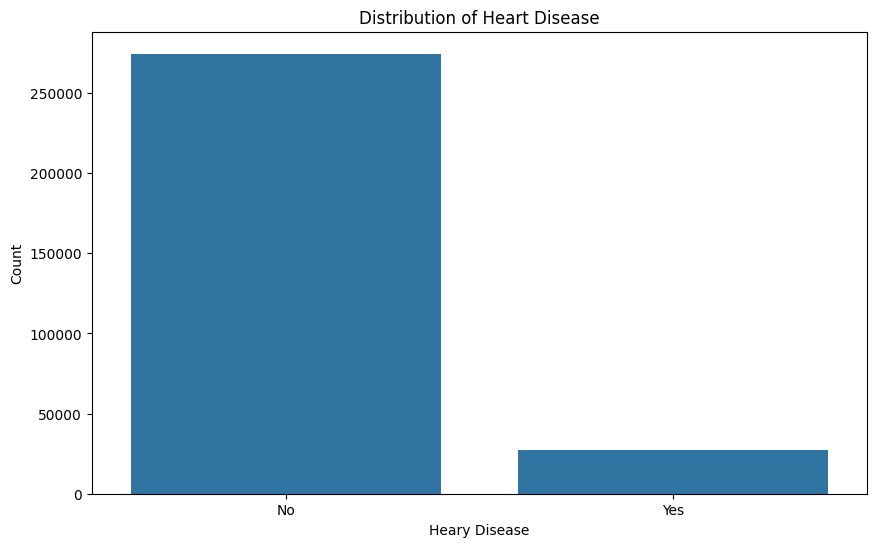

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=count_target.index,y=count_target.values)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heary Disease')
plt.ylabel('Count')
plt.show()

In [ ]:
df['PhysicalHealth'].unique()

array([ 3.,  0., 20., 28.,  6., 15.,  5., 30.,  7.,  1.,  2., 21.,  4.,
       10., 14., 18.,  8., 25., 16., 29., 27., 17., 24., 12., 23., 26.,
       22., 19.,  9., 13., 11.])

In [ ]:
df['MentalHealth'].unique()

array([30.,  0.,  2.,  5., 15.,  8.,  4.,  3., 10., 14., 20.,  1.,  7.,
       24.,  9., 28., 16., 12.,  6., 25., 17., 18., 21., 29., 22., 13.,
       23., 27., 26., 11., 19.])

In [ ]:
df['BMI'].unique()

array([16.6 , 20.34, 26.58, ..., 62.42, 51.46, 46.56])

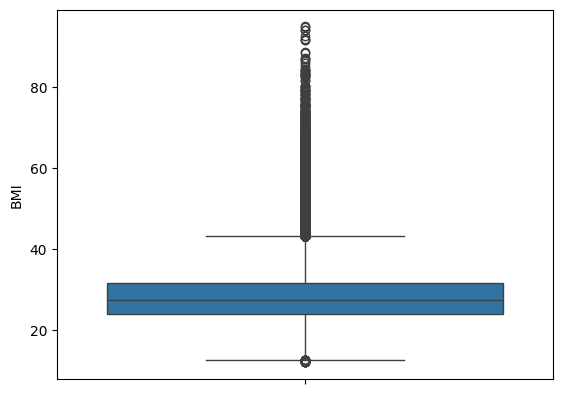

In [ ]:
sns.boxplot(df['BMI'])
plt.show()

## Handling Outliers

In [ ]:
def remove_outliers_from_dataframe(df):

    for column in df.columns:
        if column in ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']:
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

In [ ]:
df=remove_outliers_from_dataframe(df)

In [ ]:
bins = [0, 18.5, 24.9, 29.9, 34.9, 39.9, float('inf')]
labels = ['Underweight', 'Normal weight', 'Overweight', 'Obesity I', 'Obesity II', 'Obesity III']

In [ ]:
df['BMI_Category'] = pd.cut(df['BMI'], bins=bins, labels=labels, right=False)

In [ ]:
df[['BMI', 'BMI_Category']].head(10)

,BMI,BMI_Category
1,20.34,Normal weight
3,24.21,Normal weight
7,31.64,Obesity I
8,26.45,Overweight
9,40.69,Obesity III
11,28.71,Overweight
12,28.37,Overweight
15,29.18,Overweight
16,26.26,Overweight
18,29.86,Overweight


In [ ]:
df['BMI_Category'].value_counts()

,count
BMI_Category,
Overweight,79806
Normal weight,66192
Obesity I,42928
Obesity II,17035
Obesity III,4722
Underweight,3273


## Data Visualization

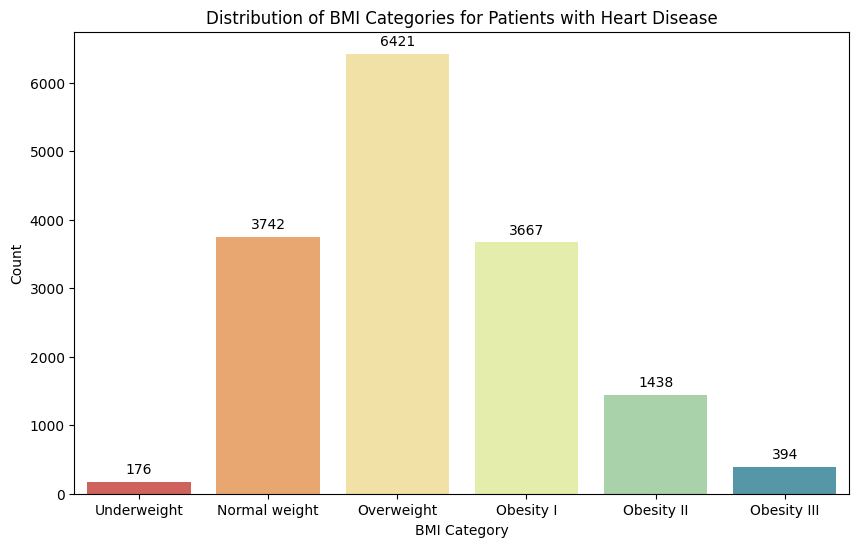

In [ ]:
df_heart_disease = df[df['HeartDisease'] == 'Yes']

plt.figure(figsize=(10,6))
ax = sns.countplot(x='BMI_Category', data=df_heart_disease, palette='Spectral')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Distribution of BMI Categories for Patients with Heart Disease')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

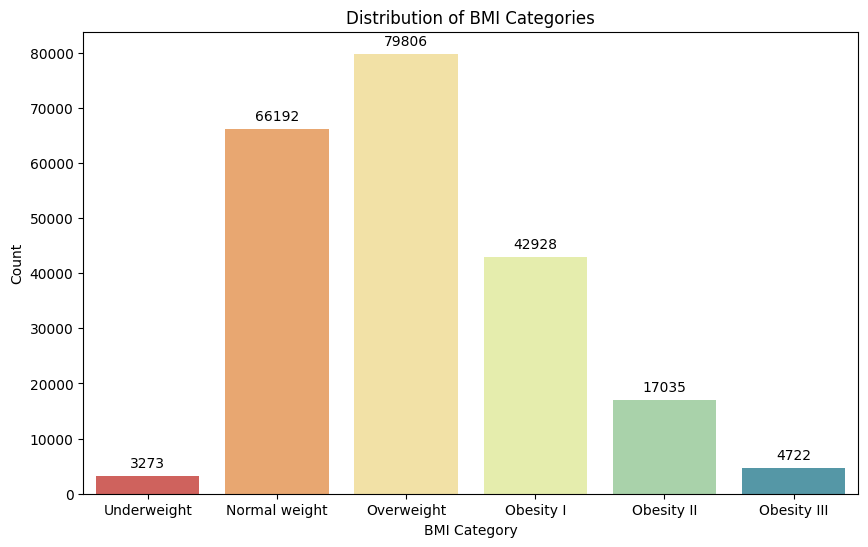

In [ ]:
plt.figure(figsize=(10,6)) # GENERAL DISTRIBUTION
ax = sns.countplot(x='BMI_Category', data=df, palette='Spectral')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Distribution of BMI Categories')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

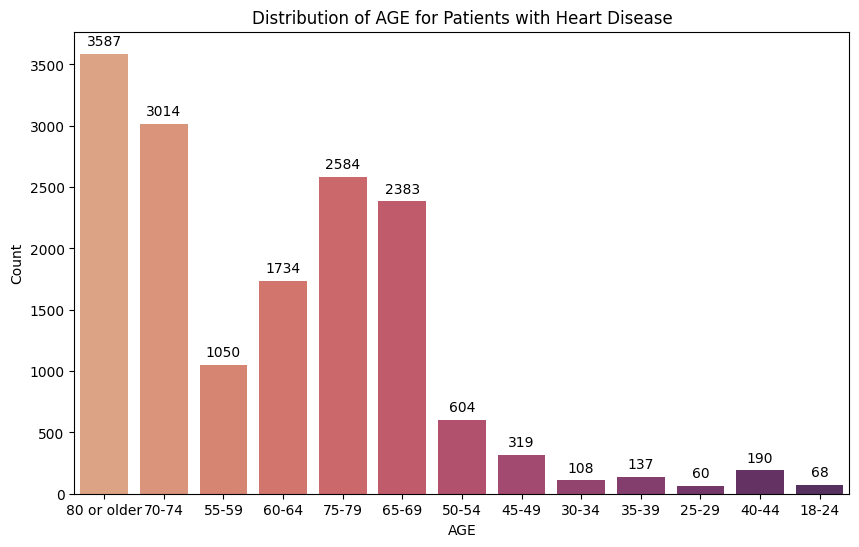

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x='AgeCategory', data=df_heart_disease, palette='flare')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Distribution of AGE for Patients with Heart Disease')
plt.xlabel('AGE')
plt.ylabel('Count')
plt.show()

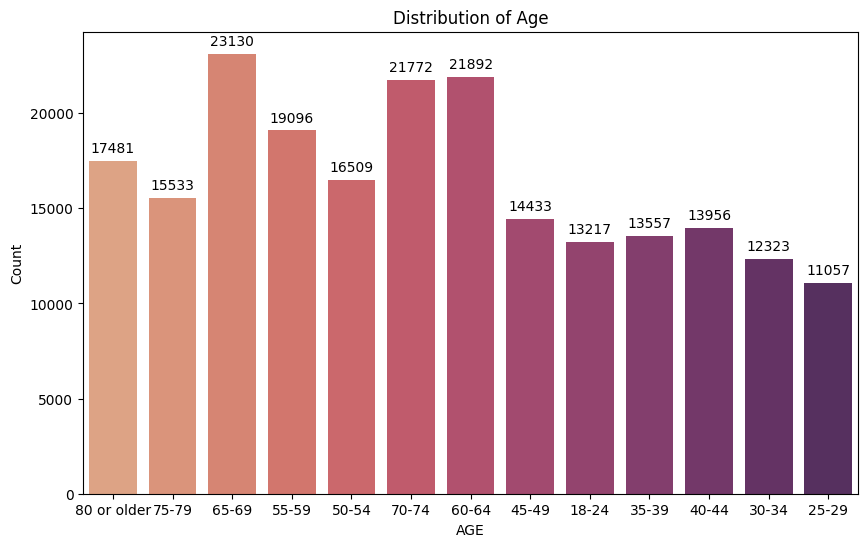

In [ ]:
plt.figure(figsize=(10,6)) # GENERAL DISTRIBUTION
ax = sns.countplot(x='AgeCategory', data=df, palette='flare')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Distribution of Age')
plt.xlabel('AGE')
plt.ylabel('Count')
plt.show()

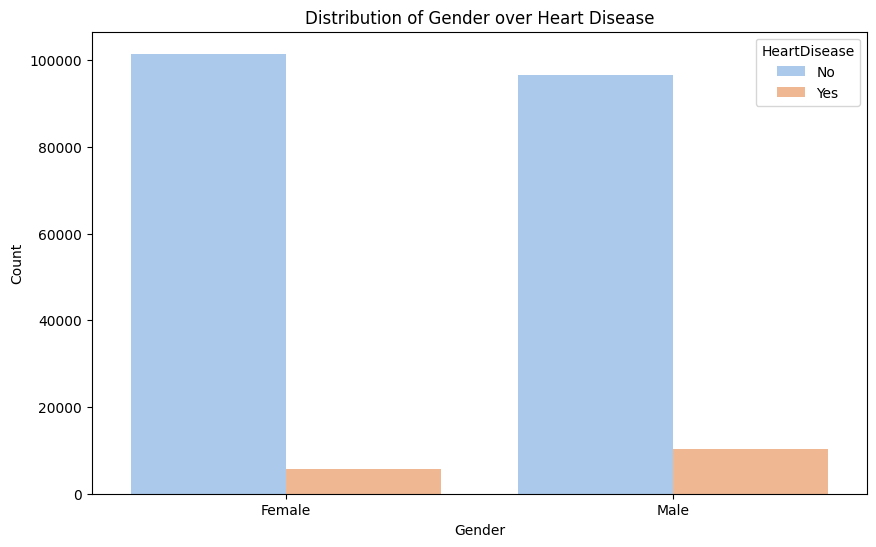

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='Sex',hue='HeartDisease',data =df,palette='pastel')
plt.title('Distribution of Gender over Heart Disease')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

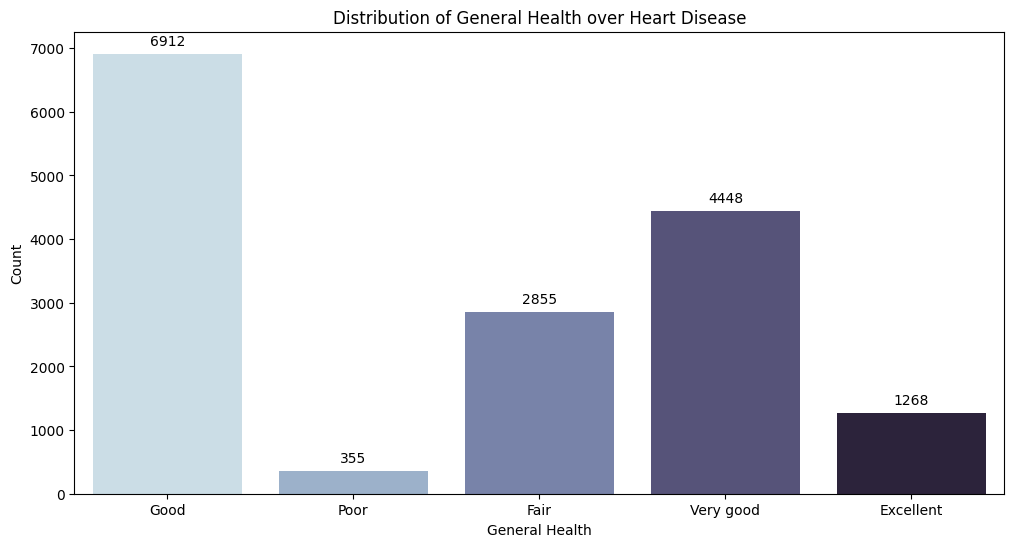

In [ ]:
plt.figure(figsize=(12,6))
ax = sns.countplot(x='GenHealth', data=df_heart_disease, palette='ch:s=.25,rot=-.25')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.title('Distribution of General Health over Heart Disease')
plt.xlabel('General Health')
plt.ylabel('Count')
plt.show()

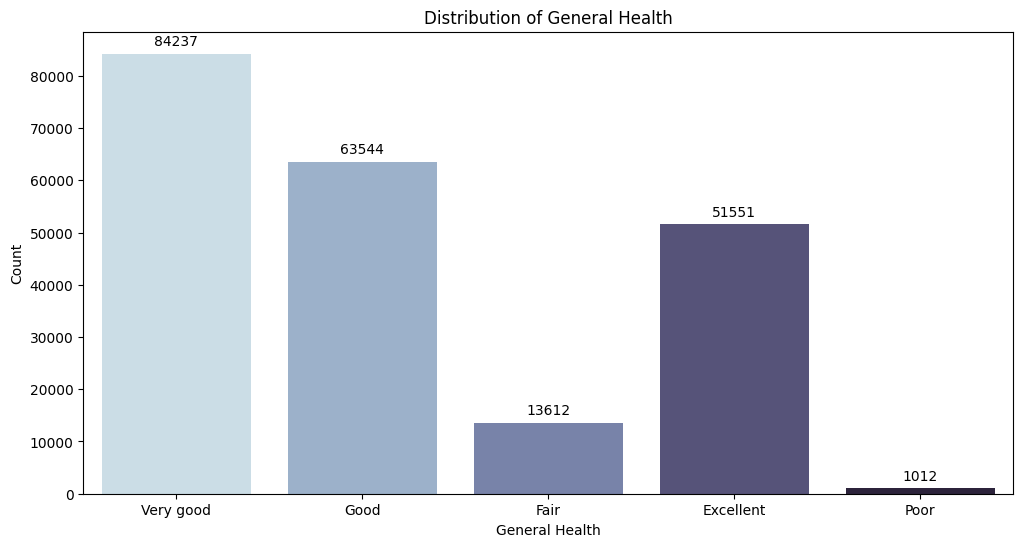

In [ ]:
plt.figure(figsize=(12,6)) # GENERAL DISTRIBUTION
ax = sns.countplot(x='GenHealth', data=df, palette='ch:s=.25,rot=-.25')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.title('Distribution of General Health')
plt.xlabel('General Health')
plt.ylabel('Count')
plt.show()

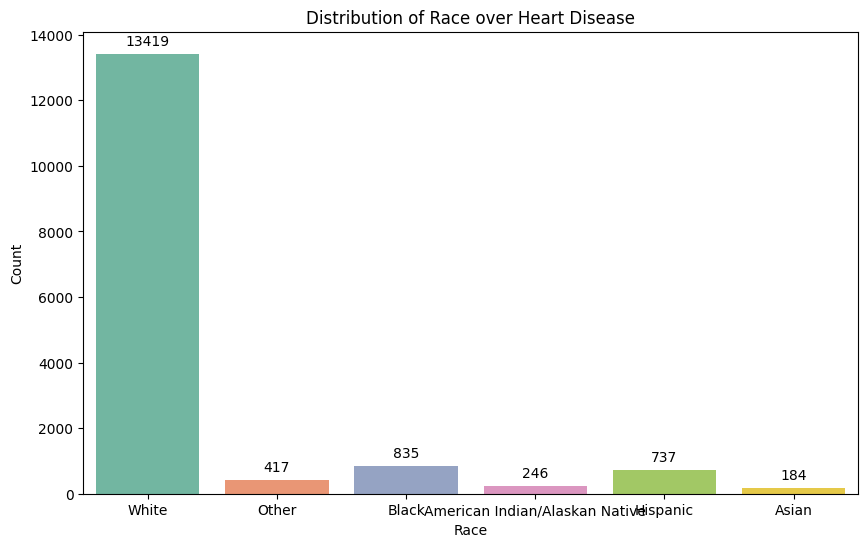

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x= 'Race',data=df_heart_disease,palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.title('Distribution of Race over Heart Disease')
plt.xlabel('Race')
plt.ylabel('Count')
plt.show()

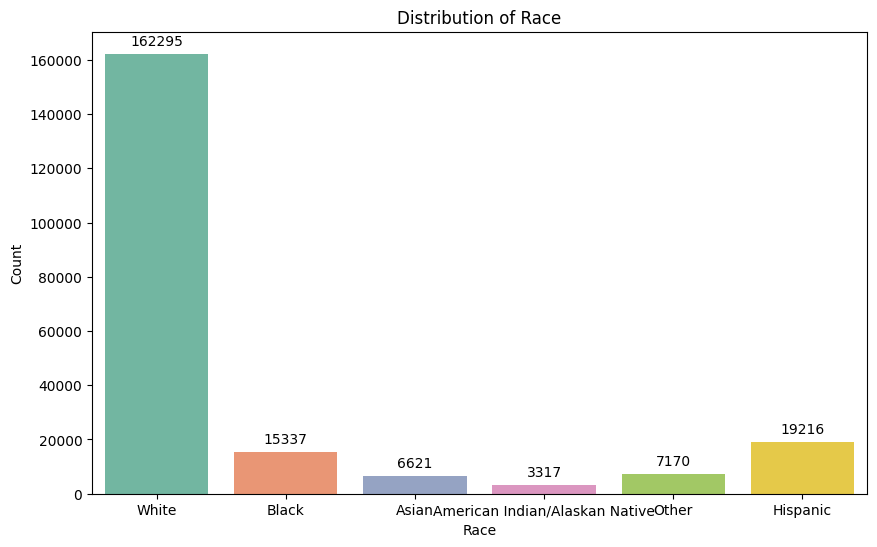

In [ ]:
plt.figure(figsize=(10,6)) # GENERAL DISTRIBUTION
ax = sns.countplot(x= 'Race',data=df,palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.title('Distribution of Race')
plt.xlabel('Race')
plt.ylabel('Count')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 213956 entries, 1 to 319792
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   HeartDisease      213956 non-null  object  
 1   BMI               213956 non-null  float64 
 2   Smoking           213956 non-null  object  
 3   AlcoholDrinking   213956 non-null  object  
 4   Stroke            213956 non-null  object  
 5   PhysicalHealth    213956 non-null  float64 
 6   MentalHealth      213956 non-null  float64 
 7   DiffWalking       213956 non-null  object  
 8   Sex               213956 non-null  object  
 9   AgeCategory       213956 non-null  object  
 10  Race              213956 non-null  object  
 11  Diabetic          213956 non-null  object  
 12  PhysicalActivity  213956 non-null  object  
 13  GenHealth         213956 non-null  object  
 14  SleepTime         213956 non-null  float64 
 15  Asthma            213956 non-null  object  
 16  KidneyD

In [ ]:
df['Diabetic'].value_counts()

,count
Diabetic,
No,183353
Yes,24317
"No, borderline diabetes",4586
Yes (during pregnancy),1700


In [ ]:
df['Diabetic'] = df['Diabetic'].replace({
    'No, borderline diabetes': 'No',
    'Yes (during pregnancy)': 'Yes'
})

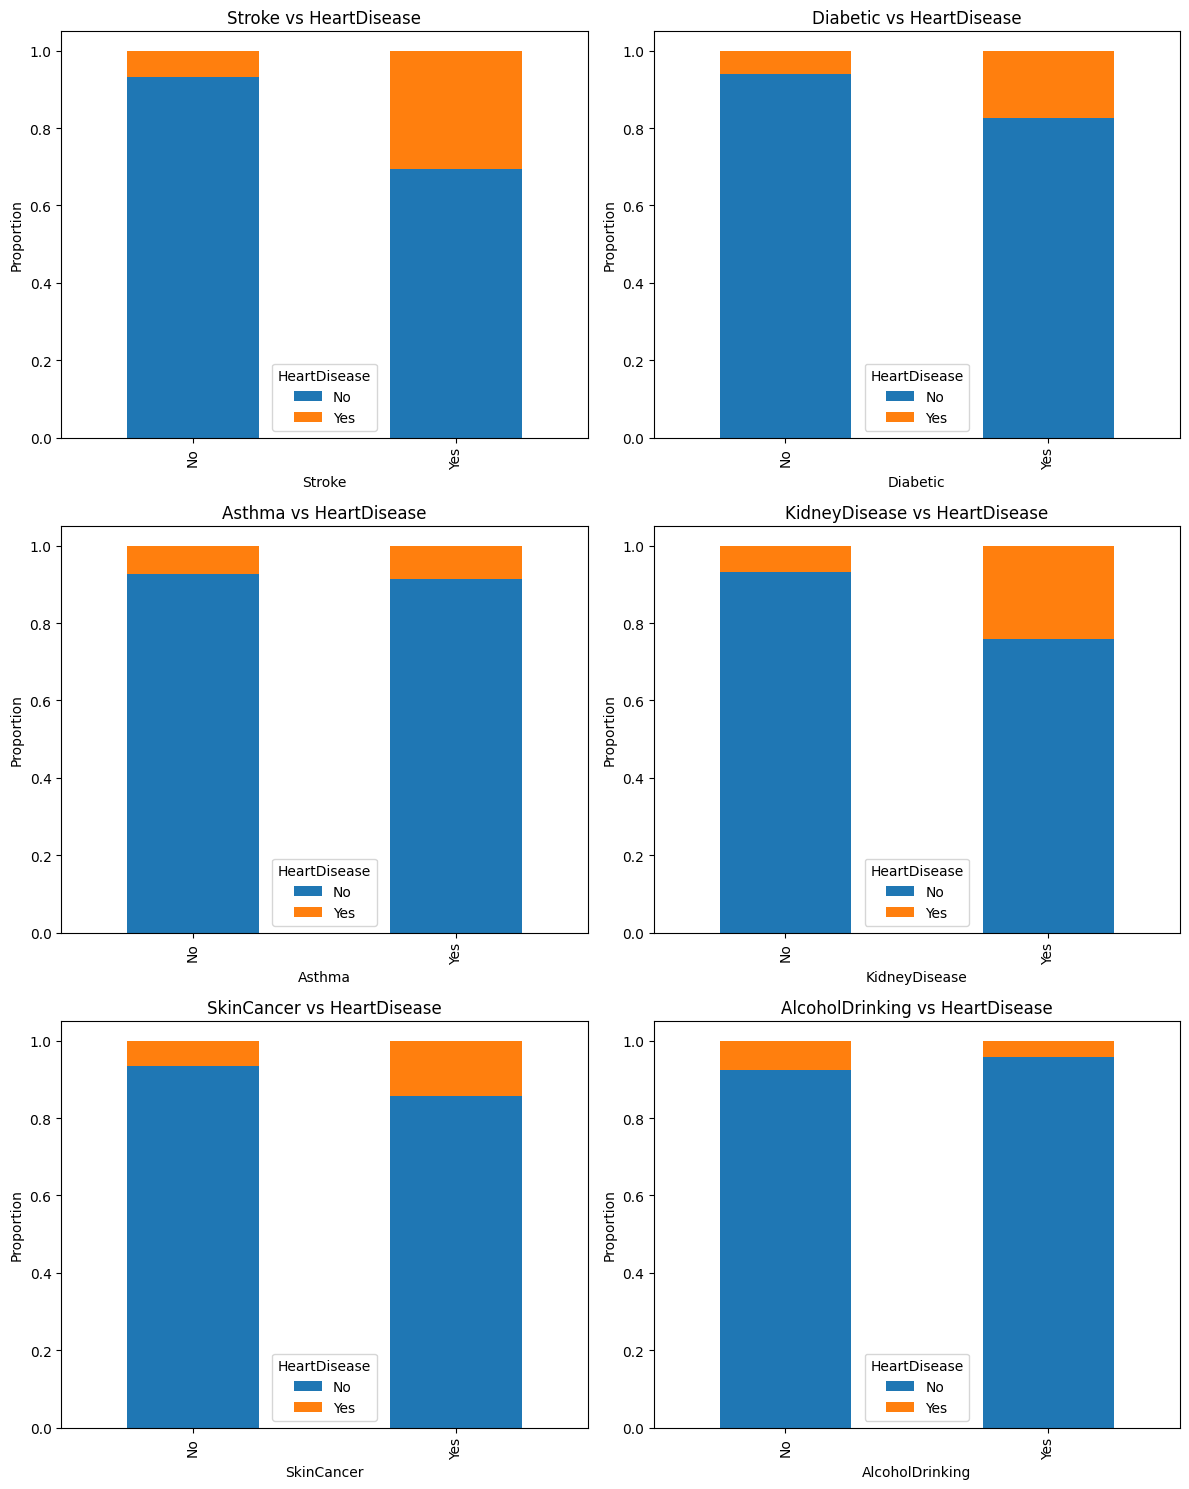

In [ ]:
def stacked_bar(data, feature, target, ax):
    crosstab = pd.crosstab(data[feature], data[target], normalize='index')
    crosstab.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'{feature} vs {target}')
    ax.set_ylabel('Proportion')

# Set up the figure
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

# Plot each feature
stacked_bar(df, 'Stroke', 'HeartDisease', axes[0, 0])
stacked_bar(df, 'Diabetic', 'HeartDisease', axes[0, 1])
stacked_bar(df, 'Asthma', 'HeartDisease', axes[1, 0])
stacked_bar(df, 'KidneyDisease', 'HeartDisease', axes[1, 1])
stacked_bar(df, 'SkinCancer', 'HeartDisease', axes[2, 0])
stacked_bar(df, 'AlcoholDrinking', 'HeartDisease', axes[2, 1])


# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
df['SleepTime'].value_counts()

,count
SleepTime,
7.0,69750
8.0,69644
6.0,43557
9.0,11693
5.0,10505
10.0,4738
4.0,3170
3.0,681
11.0,218


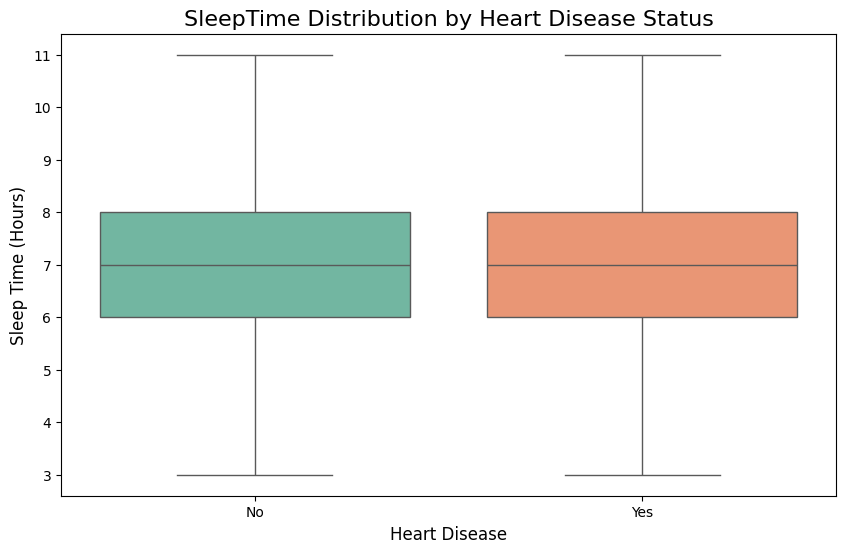

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='HeartDisease', y='SleepTime', data=df, palette='Set2')
plt.title('SleepTime Distribution by Heart Disease Status', fontsize=16)
plt.xlabel('Heart Disease', fontsize=12)
plt.ylabel('Sleep Time (Hours)', fontsize=12)

plt.show()

In [ ]:
df[['PhysicalHealth','MentalHealth']].describe()

,PhysicalHealth,MentalHealth
count,213956.000000,213956.00000
mean,0.420937,0.81306
std,1.098286,1.68923
min,0.000000,0.00000
25%,0.000000,0.00000
50%,0.000000,0.00000
75%,0.000000,0.00000
max,5.000000,7.00000


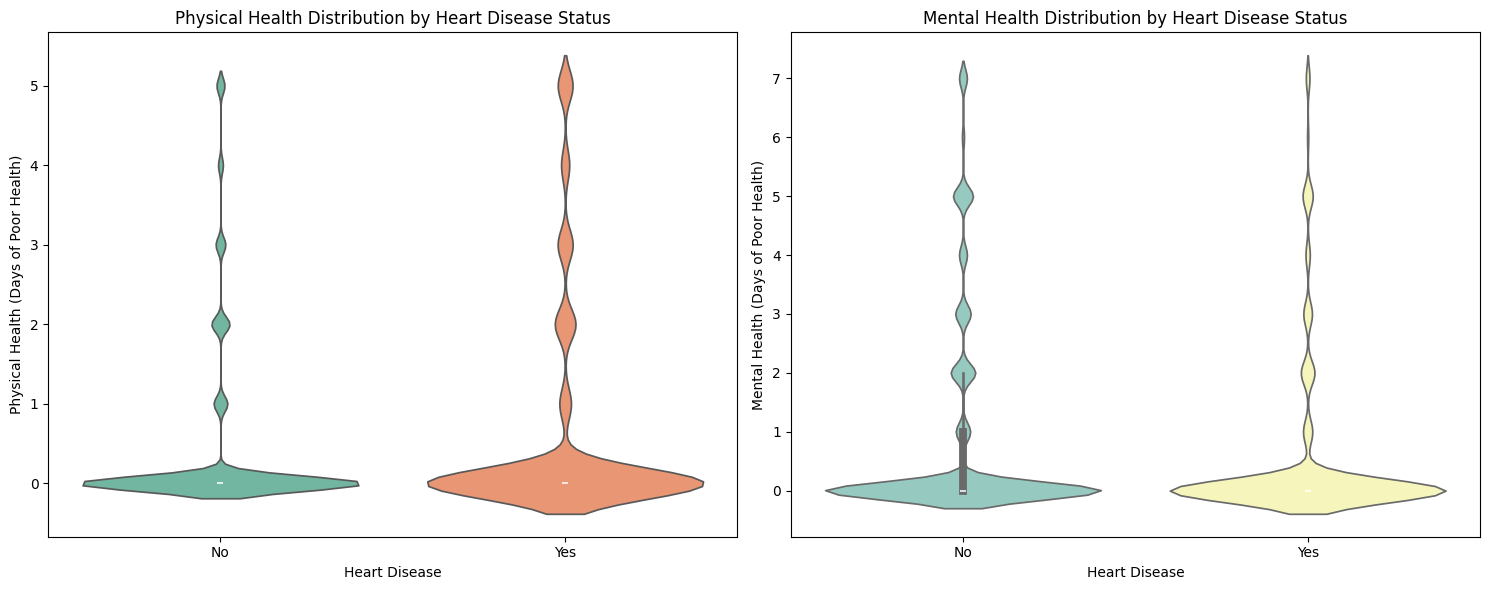

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.violinplot(x='HeartDisease', y='PhysicalHealth', data=df, palette='Set2')
plt.title('Physical Health Distribution by Heart Disease Status')
plt.xlabel('Heart Disease')
plt.ylabel('Physical Health (Days of Poor Health)')


plt.subplot(1, 2, 2)
sns.violinplot(x='HeartDisease', y='MentalHealth', data=df, palette='Set3')
plt.title('Mental Health Distribution by Heart Disease Status')
plt.xlabel('Heart Disease')
plt.ylabel('Mental Health (Days of Poor Health)')


plt.tight_layout()
plt.show()

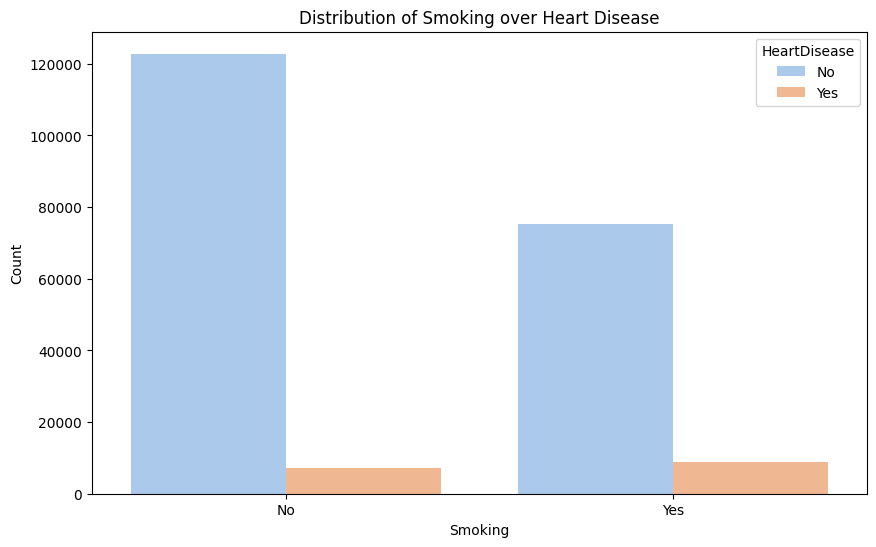

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='Smoking',hue='HeartDisease',data =df,palette='pastel')
plt.title('Distribution of Smoking over Heart Disease')
plt.xlabel('Smoking')
plt.ylabel('Count')
plt.show()

In [ ]:
df.corr(numeric_only=True)

,BMI,PhysicalHealth,MentalHealth,SleepTime
BMI,1.000000,0.036012,-0.025794,-0.053542
PhysicalHealth,0.036012,1.000000,0.123860,-0.026923
MentalHealth,-0.025794,0.123860,1.000000,-0.053419
SleepTime,-0.053542,-0.026923,-0.053419,1.000000


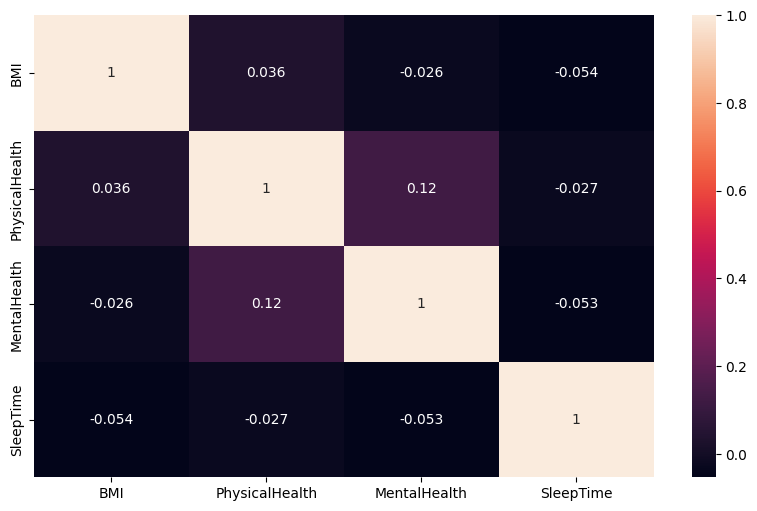

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [ ]:
df.drop(columns=['BMI','Sex'],inplace=True)

In [ ]:
df['Race'].value_counts()

,count
Race,
White,162295
Hispanic,19216
Black,15337
Other,7170
Asian,6621
American Indian/Alaskan Native,3317


## Preprocessing

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

ordinal_cols = ['BMI_Category', 'AgeCategory', 'Race', 'GenHealth']
boolean_cols = ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Diabetic', 'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer']

ordinal_mappings = {
    'BMI_Category': ['Underweight', 'Normal weight', 'Overweight', 'Obesity I', 'Obesity II', 'Obesity III'],
    'AgeCategory': ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older'],
    'Race': ['White', 'Black', 'Asian','Hispanic', 'American Indian/Alaskan Native', 'Other'],
    'GenHealth': ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']
}


preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[ordinal_mappings[col] for col in ordinal_cols]), ordinal_cols),  # Ordinal encoding
        ('ohe', OneHotEncoder(drop='first'), boolean_cols)  # OneHotEncoding for boolean columns
    ],
    remainder='passthrough'
)


df_transformed = preprocessor.fit_transform(df)

# Convert the transformed data back to a DataFrame with appropriate column names
# Ordinal columns retain original names, while OneHotEncoder generates new columns
ohe_columns = preprocessor.named_transformers_['ohe'].get_feature_names_out(boolean_cols)
final_columns = ordinal_cols + list(ohe_columns) + [col for col in df.columns if col not in ordinal_cols + boolean_cols]

df_encoded = pd.DataFrame(df_transformed, columns=final_columns)



In [ ]:
df_encoded.head()

,BMI_Category,AgeCategory,Race,GenHealth,HeartDisease_Yes,Smoking_Yes,AlcoholDrinking_Yes,Stroke_Yes,DiffWalking_Yes,Diabetic_Yes,PhysicalActivity_Yes,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes,PhysicalHealth,MentalHealth,SleepTime
0,1.0,12.0,0.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,7.0
1,1.0,11.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,6.0
2,3.0,12.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,5.0,0.0,9.0
3,2.0,12.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.0
4,5.0,9.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,10.0


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213956 entries, 0 to 213955
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   BMI_Category          213956 non-null  float64
 1   AgeCategory           213956 non-null  float64
 2   Race                  213956 non-null  float64
 3   GenHealth             213956 non-null  float64
 4   HeartDisease_Yes      213956 non-null  float64
 5   Smoking_Yes           213956 non-null  float64
 6   AlcoholDrinking_Yes   213956 non-null  float64
 7   Stroke_Yes            213956 non-null  float64
 8   DiffWalking_Yes       213956 non-null  float64
 9   Diabetic_Yes          213956 non-null  float64
 10  PhysicalActivity_Yes  213956 non-null  float64
 11  Asthma_Yes            213956 non-null  float64
 12  KidneyDisease_Yes     213956 non-null  float64
 13  SkinCancer_Yes        213956 non-null  float64
 14  PhysicalHealth        213956 non-null  float64
 15  

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
X = df_encoded.drop('HeartDisease_Yes', axis=1)
y = df_encoded['HeartDisease_Yes']

In [ ]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_scaled= scale.fit_transform(X)

<Axes: >

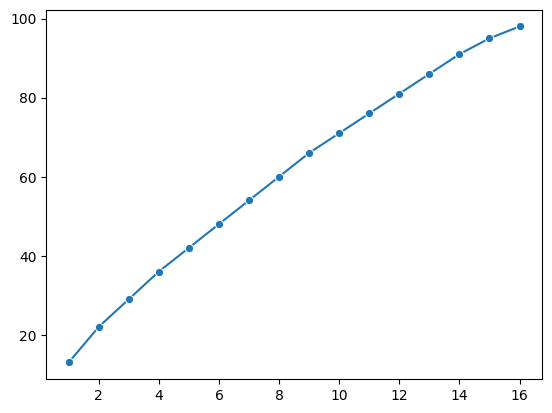

In [ ]:

from sklearn.decomposition import PCA
decom = PCA(svd_solver='auto')
X_pca = decom.fit_transform(X_scaled)
ex_var = np.cumsum(np.round(decom.explained_variance_ratio_, 2) * 100)
sns.lineplot(y=ex_var, x=np.arange(1, len(ex_var) + 1), marker='o')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## df_encoded Pairwise Correlation Analysis

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

def improved_pairwise_correlation(df):
    # Copy and encode all non-numeric features
    df_encoded = df.copy()
    le = LabelEncoder()
    for col in df.columns:
        if df[col].dtype == 'object' or df[col].dtype.name == 'category':
            df_encoded[col] = le.fit_transform(df[col])

    # Compute correlation matrix
    corr_matrix = df_encoded.corr()

    # Reorder correlation matrix based on correlation with HeartDisease
    heart_disease_corr = corr_matrix['HeartDisease'].abs().sort_values(ascending=False)
    ordered_cols = heart_disease_corr.index.tolist()
    corr_matrix = corr_matrix.loc[ordered_cols, ordered_cols]

    # Create a mask for the upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Plot heatmap with improvements
    plt.figure(figsize=(16, 14))

    # Custom colormap with stronger colors for important correlations
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    # Plot the heatmap with improved formatting
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, center=0, linewidths=0.8, square=True,
                annot_kws={"size": 10})

    plt.title('Improved Pairwise Feature Correlation Matrix', fontsize=20)
    plt.tight_layout()

    # Add a box to highlight HeartDisease correlations
    plt.axhline(y=1, color='black', linewidth=2)
    plt.axvline(x=0, color='black', linewidth=2)

    plt.show()

    # Also show the top correlations with HeartDisease
    print("Top Correlations with Heart Disease:")
    top_correlations = corr_matrix.iloc[0, 1:10]
    for feature, corr in top_correlations.items():
        print(f"{feature}: {corr:.3f}")

    return corr_matrix

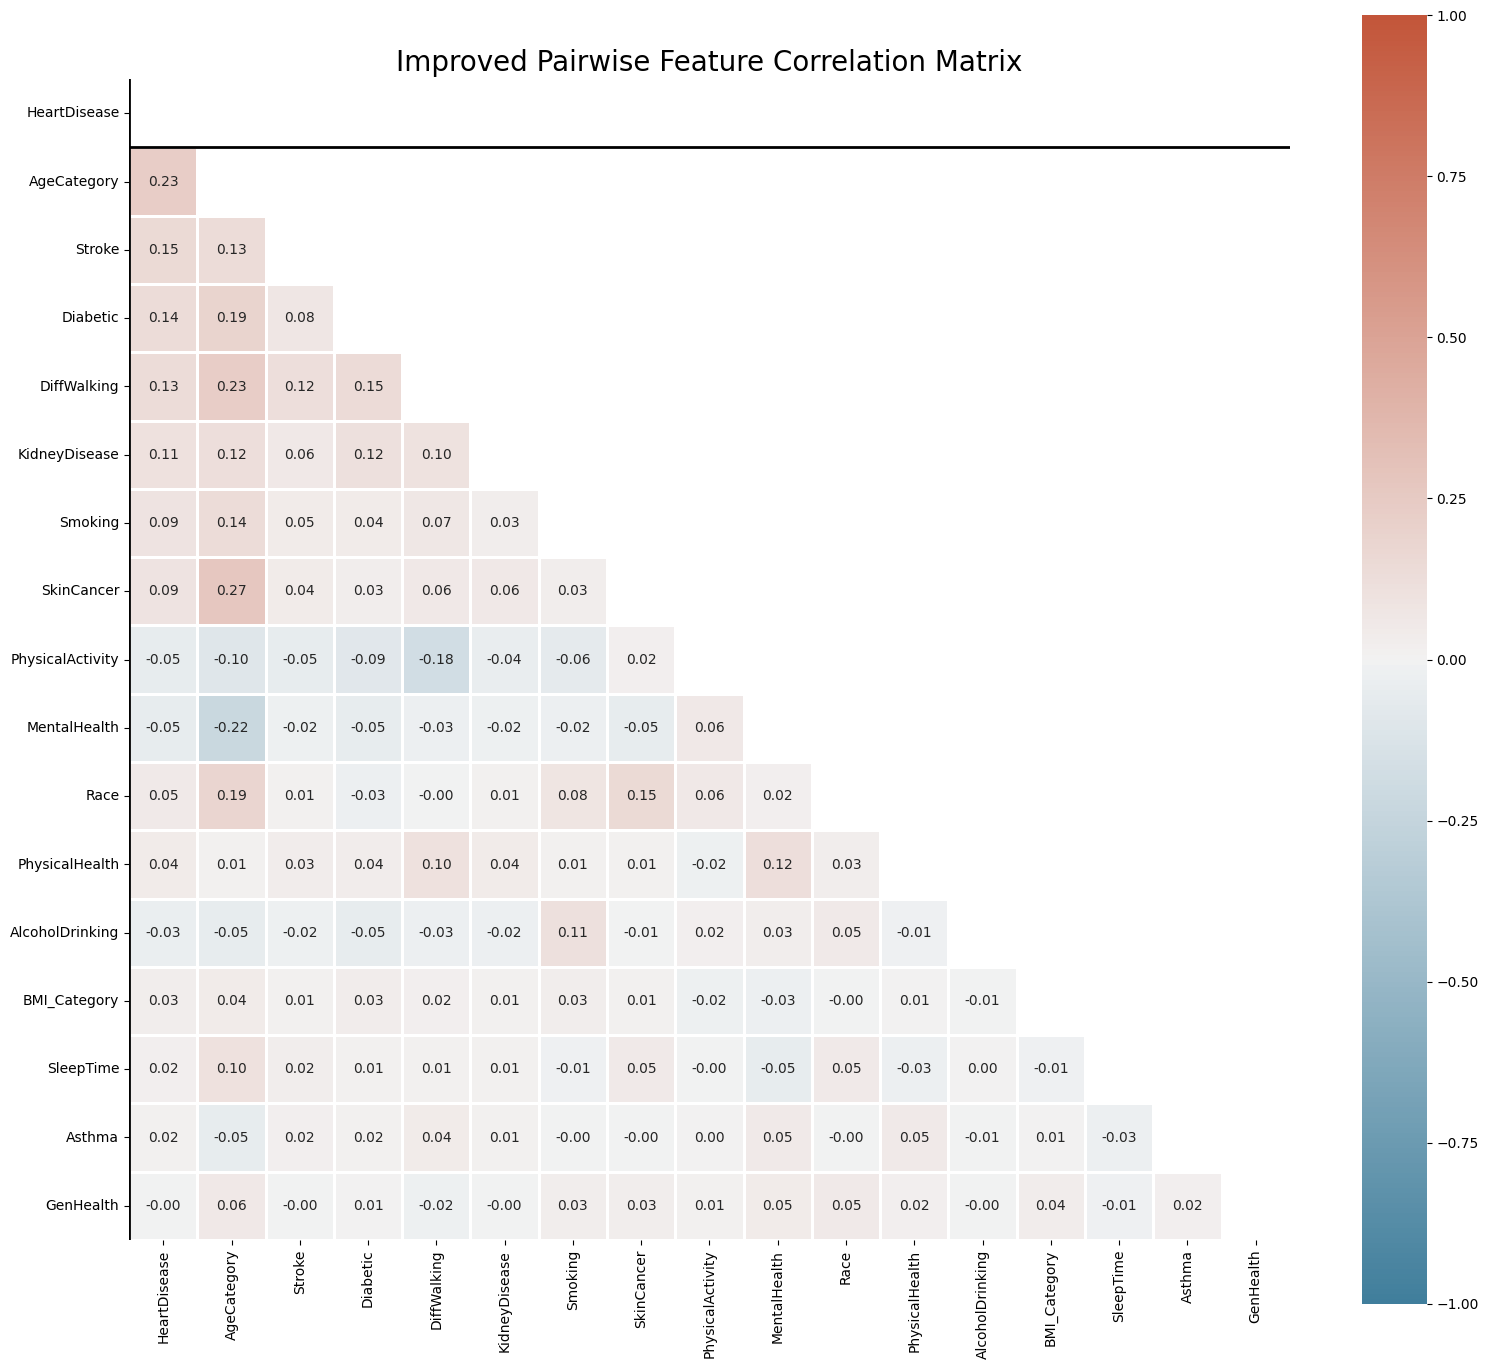

Top Correlations with Heart Disease:
AgeCategory: 0.229
Stroke: 0.155
Diabetic: 0.140
DiffWalking: 0.135
KidneyDisease: 0.109
Smoking: 0.093
SkinCancer: 0.088
PhysicalActivity: -0.054
MentalHealth: -0.052


In [ ]:
pairwise_corr = improved_pairwise_correlation(df)

## ReSampling

In [ ]:
from imblearn.combine import SMOTEENN
smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train, y_train)


## Build Models

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    # Generate confusion matrix and classification report
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    # Display the results
    print(f'{model_name} Accuracy: {accuracy:.2f}')
    print(f'{model_name} Classification Report:\n{class_report}')

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['No Heart Disease', 'Heart Disease'])
    disp.plot()
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    return accuracy

## LogisticRegression

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train_resampled, y_train_resampled)

LogisticRegression()

Logistic Regression Accuracy: 0.75
Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.75      0.85     39617
         1.0       0.19      0.73      0.30      3175

    accuracy                           0.75     42792
   macro avg       0.58      0.74      0.57     42792
weighted avg       0.91      0.75      0.81     42792



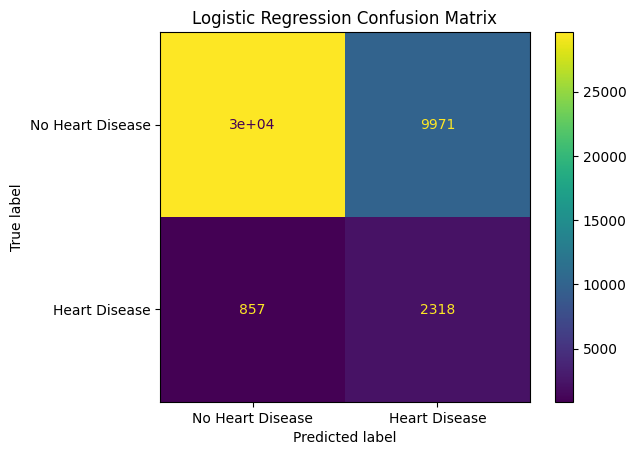

0.746962048981118

In [ ]:
log_reg_accuracy =evaluate_model(log_reg, X_test, y_test, 'Logistic Regression')
log_reg_accuracy

## RandomForest

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier()

Random Forest Classifier Accuracy: 0.88
Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.92      0.93     39617
         1.0       0.26      0.33      0.29      3175

    accuracy                           0.88     42792
   macro avg       0.60      0.63      0.61     42792
weighted avg       0.89      0.88      0.89     42792



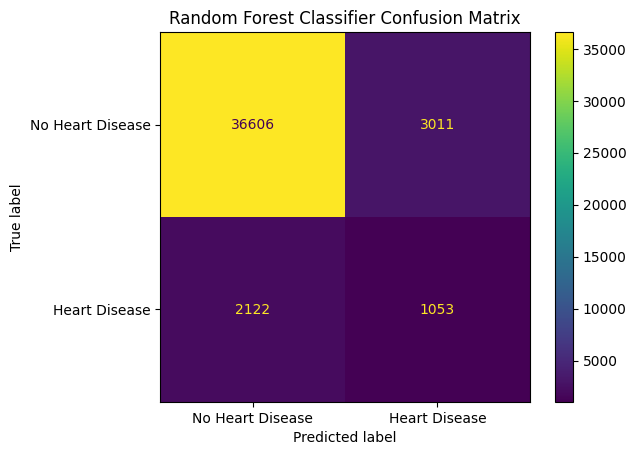

0.8800476724621424

In [ ]:
rf_accuracy= evaluate_model(rf, X_test, y_test, 'Random Forest Classifier')
rf_accuracy

## GradientBoosting

In [ ]:
gbc = GradientBoostingClassifier()
gbc.fit(X_train_resampled, y_train_resampled)

GradientBoostingClassifier()

Gradient Boosting Classifier Accuracy: 0.86
Gradient Boosting Classifier Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.89      0.92     39617
         1.0       0.26      0.47      0.33      3175

    accuracy                           0.86     42792
   macro avg       0.61      0.68      0.63     42792
weighted avg       0.90      0.86      0.88     42792



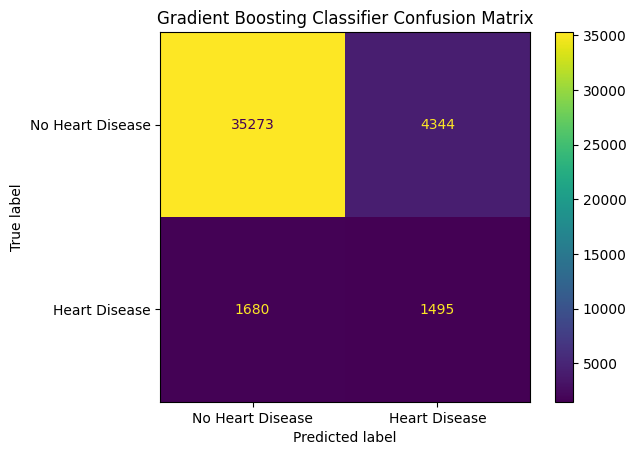

0.8592260235558048

In [ ]:
gbc_accuracy = evaluate_model(gbc, X_test, y_test, 'Gradient Boosting Classifier')
gbc_accuracy

## XGBoost

In [ ]:
import xgboost as xgb
xgboost_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgboost_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

XGBoost Classifier Accuracy: 0.90
XGBoost Classifier Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.95     39617
         1.0       0.32      0.27      0.29      3175

    accuracy                           0.90     42792
   macro avg       0.63      0.61      0.62     42792
weighted avg       0.90      0.90      0.90     42792



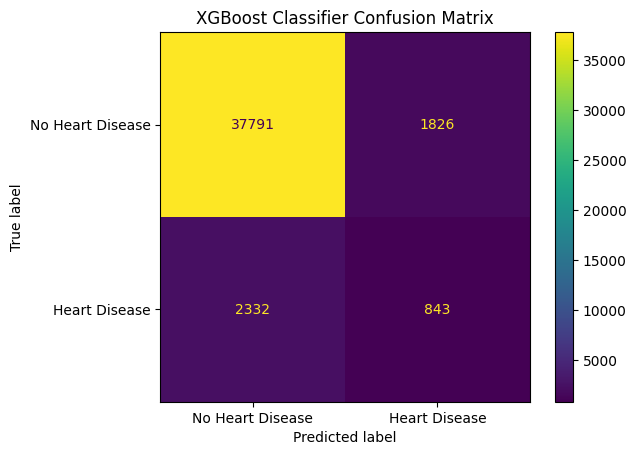

XGBoost Classifier Accuracy: 0.9028323051037577


In [ ]:
xgboost_accuracy = evaluate_model(xgboost_model, X_test, y_test, 'XGBoost Classifier')
print(f'XGBoost Classifier Accuracy: {xgboost_accuracy}')

---------

##Accuracy Across Race and Sex Subgroups for XGBoost

In [ ]:
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Recall, F1 Score, AUC for Sex
y_pred = xgboost_model.predict(X_test)
y_proba = xgboost_model.predict_proba(X_test)[:, 1]

df_sex = pd.read_csv('/kaggle/input/personal-key-indicators-of-heart-disease/2020/heart_2020_cleaned.csv')
df_sex['Sex'] = df_sex['Sex'].map({'Male': 0.0, 'Female': 1.0}).astype(float)
X_test_sex = pd.DataFrame(X_test, columns=X.columns)
X_test_sex['Sex']=df_sex['Sex']
results_sex = X_test_sex.copy()
y_test = y_test.reset_index(drop=True)
results_sex['y_true'] = y_test
results_sex['y_pred'] = y_pred
results_sex['y_proba'] = y_proba

for sex_val, sex_label in zip([0, 1], ["Female", "Male"]):
    subset = results_sex[results_sex['Sex'] == sex_val]
    recall = recall_score(subset['y_true'], subset['y_pred'])
    f1 = f1_score(subset['y_true'], subset['y_pred'])
    auc = roc_auc_score(subset['y_true'], subset['y_proba']) if len(subset['y_true'].unique()) > 1 else float('nan')

    print(f"\n{sex_label} Metrics:")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  AUC: {auc:.4f}")

# Recall, F1 Score, AUC for Race
y_pred = xgboost_model.predict(X_test)
y_proba = xgboost_model.predict_proba(X_test)[:, 1]

df_race = pd.read_csv('/kaggle/input/personal-key-indicators-of-heart-disease/2020/heart_2020_cleaned.csv')
df_race['Race'] = df_race['Race'].map({
    'White': 0.0,
    'Black': 1.0,
    'Asian': 2.0,
    'Hispanic': 3.0,
    'American Indian/Alaskan Native': 4.0,
    'Other': 5.0
}).astype(float)
X_test_race = pd.DataFrame(X_test, columns=X.columns)
X_test_race['Race']=df_race['Race']
results_race = X_test_race.copy()
y_test = y_test.reset_index(drop=True)
results_race = pd.DataFrame(results_race, columns=X.columns)
results_race['y_true'] = y_test.values
results_race['y_pred'] = y_pred
results_race['y_proba'] = y_proba

for race_val, race_label in zip(range(6), ['White', 'Black', 'Asian', 'Hispanic', 'American Indian/Alaskan Native', 'Other']):
    subset = results_race[results_race['Race'] == race_val]

    if len(subset) == 0:
        print(f"No samples found for {race_label}")
        continue

    recall = recall_score(subset['y_true'], subset['y_pred'])
    f1 = f1_score(subset['y_true'], subset['y_pred'])

    if len(subset['y_true'].unique()) > 1:
        auc = roc_auc_score(subset['y_true'], subset['y_proba'])
    else:
        auc = float('nan')

    print(f"\n{race_label} Metrics:")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  AUC: {auc:.4f}")


Female Metrics:
  Recall: 0.2604
  F1 Score: 0.2871
  AUC: 0.8055

Male Metrics:
  Recall: 0.2703
  F1 Score: 0.2897
  AUC: 0.8013

White Metrics:
  Recall: 0.2566
  F1 Score: 0.2790
  AUC: 0.8060

Black Metrics:
  Recall: 0.2984
  F1 Score: 0.3263
  AUC: 0.8128

Asian Metrics:
  Recall: 0.2542
  F1 Score: 0.2586
  AUC: 0.7812

Hispanic Metrics:
  Recall: 0.2769
  F1 Score: 0.2951
  AUC: 0.7833

American Indian/Alaskan Native Metrics:
  Recall: 0.3085
  F1 Score: 0.3537
  AUC: 0.8141

Other Metrics:
  Recall: 0.3000
  F1 Score: 0.3349
  AUC: 0.7971


##Fairness Metrics Across Race and Sex Subgroups

In [ ]:
from sklearn.metrics import precision_score

# False Negative Rate for Sex
sex_labels = ['Male', 'Female']

for sex_val, sex_label in zip([0.0, 1.0], sex_labels):
    subset = results_sex[results_sex['Sex'] == sex_val]

    y_true = subset['y_true']
    y_pred = subset['y_pred']

    FN = ((y_true == 1) & (y_pred == 0)).sum()
    TP = ((y_true == 1) & (y_pred == 1)).sum()

    fnr = FN / (FN + TP) if (FN + TP) > 0 else float('nan')

    print(f"{sex_label} - False Negative Rate: {fnr:.4f}")

# Equal Opportunities for Sex
for sex_val, sex_label in zip([0.0, 1.0], sex_labels):
    subset = results_sex[results_sex['Sex'] == sex_val]

    tpr = recall_score(subset['y_true'], subset['y_pred'])
    print(f"{sex_label} - True Positive Rate: {tpr:.4f}")

# Predictive Parity for Sex
precision_scores = {}

for sex_val, sex_label in zip([0.0, 1.0], sex_labels):
    subset = results_sex[results_sex['Sex'] == sex_val]

    precision = precision_score(subset['y_true'], subset['y_pred'])
    precision_scores[sex_label] = precision
    print(f"{sex_label} - Predictive Parity: {precision:.4f}")

# False Negative Rate for Race
race_labels = ['White', 'Black', 'Asian', 'Hispanic', 'American Indian/Alaskan Native', 'Other']

for race_val, race_label in enumerate(race_labels):
    subset = results_race[results_race['Race'] == race_val]

    y_true = subset['y_true']
    y_pred = subset['y_pred']

    # Calculate FN and TP
    FN = ((y_true == 1) & (y_pred == 0)).sum()
    TP = ((y_true == 1) & (y_pred == 1)).sum()

    fnr = FN / (FN + TP) if (FN + TP) > 0 else float('nan')

    print(f"{race_label} - False Negative Rate: {fnr:.4f}")
# Equal Opportunities for Race
tpr_values = {}
for race_val, race_label in enumerate(race_labels):
    subset = results_race[results_race['Race'] == race_val]

    tpr = recall_score(subset['y_true'], subset['y_pred'])
    tpr_values[race_label] = tpr
    print(f"{race_label} - True Positive Rate: {tpr:.4f}")

# Predictive Parity for Race
precision_scores = {}

for race_val, race_label in enumerate(race_labels):
    subset = results_race[results_race['Race'] == race_val]

    precision = precision_score(subset['y_true'], subset['y_pred'])
    precision_scores[race_label] = precision
    print(f"{race_label} - Predictive Parity: {precision:.4f}")

Male - False Negative Rate: 0.7396
Female - False Negative Rate: 0.7297
Male - True Positive Rate: 0.2604
Female - True Positive Rate: 0.2703
Male - Predictive Parity: 0.3200
Female - Predictive Parity: 0.3121
White - False Negative Rate: 0.7434
Black - False Negative Rate: 0.7016
Asian - False Negative Rate: 0.7458
Hispanic - False Negative Rate: 0.7231
American Indian/Alaskan Native - False Negative Rate: 0.6915
Other - False Negative Rate: 0.7000
White - True Positive Rate: 0.2566
Black - True Positive Rate: 0.2984
Asian - True Positive Rate: 0.2542
Hispanic - True Positive Rate: 0.2769
American Indian/Alaskan Native - True Positive Rate: 0.3085
Other - True Positive Rate: 0.3000
White - Predictive Parity: 0.3057
Black - Predictive Parity: 0.3598
Asian - Predictive Parity: 0.2632
Hispanic - Predictive Parity: 0.3160
American Indian/Alaskan Native - Predictive Parity: 0.4143
Other - Predictive Parity: 0.3789


### Additional Method Analysis

In [ ]:
def identify_difficult_cases(model, X, y):
    # Get prediction probabilities
    y_proba = model.predict_proba(X)

    # Cases where prediction probability is close to decision threshold (0.5)
    boundary_cases = X[(y_proba[:, 1] > 0.4) & (y_proba[:, 1] < 0.6)].copy()
    boundary_labels = y[(y_proba[:, 1] > 0.4) & (y_proba[:, 1] < 0.6)]

    # Calculate accuracy on boundary cases
    boundary_preds = model.predict(boundary_cases)
    boundary_accuracy = accuracy_score(boundary_labels, boundary_preds)

    # Compare to overall accuracy
    overall_preds = model.predict(X)
    overall_accuracy = accuracy_score(y, overall_preds)

    return {
        "boundary_cases_count": len(boundary_cases),
        "boundary_accuracy": boundary_accuracy,
        "overall_accuracy": overall_accuracy,
        "accuracy_drop": overall_accuracy - boundary_accuracy
    }

In [ ]:
results = identify_difficult_cases(xgboost_model, X_test, y_test)
results

{'boundary_cases_count': 1565,
 'boundary_accuracy': 0.5418530351437699,
 'overall_accuracy': 0.9028323051037577,
 'accuracy_drop': 0.36097926995998775}

In [ ]:
def clinical_threshold_optimization(model, X, y):
    # Get prediction probabilities
    y_proba = model.predict_proba(X)[:, 1]

    # Test various thresholds
    thresholds = np.arange(0.1, 0.9, 0.05)
    results = []

    for threshold in thresholds:
        # Apply threshold
        y_pred = (y_proba >= threshold).astype(int)

        # Calculate metrics
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

        # Calculate clinical metrics
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # True positive rate
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # True negative rate
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Positive predictive value

        # Calculate clinical utility score - weighting sensitivity higher
        # because missing heart disease is more serious than false alarms
        clinical_utility = (3 * sensitivity + specificity) / 4

        results.append({
            "threshold": threshold,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "positive_predictive_value": ppv,
            "clinical_utility": clinical_utility
        })

    # Convert to DataFrame for easier analysis
    results_df = pd.DataFrame(results)

    # Find threshold with maximum clinical utility
    optimal_threshold = results_df.loc[results_df["clinical_utility"].idxmax()]

    return results_df, optimal_threshold

In [ ]:
results_df, optimal_threshold = clinical_threshold_optimization(xgboost_model, X_test, y_test)
print(results_df)
optimal_threshold


    threshold  sensitivity  specificity  positive_predictive_value  \
0        0.10     0.637165     0.796476                   0.200575   
1        0.15     0.558110     0.844284                   0.223146   
2        0.20     0.487874     0.876063                   0.239820   
3        0.25     0.436220     0.897014                   0.253431   
4        0.30     0.394961     0.912866                   0.266468   
5        0.35     0.361575     0.925663                   0.280479   
6        0.40     0.327244     0.936568                   0.292511   
7        0.45     0.294803     0.946210                   0.305184   
8        0.50     0.265512     0.953909                   0.315849   
9        0.55     0.240315     0.961405                   0.332897   
10       0.60     0.214803     0.967060                   0.343231   
11       0.65     0.189606     0.972209                   0.353494   
12       0.70     0.167874     0.977863                   0.378014   
13       0.75     0.

,0
threshold,0.100000
sensitivity,0.637165
specificity,0.796476
positive_predictive_value,0.200575
clinical_utility,0.676993


## LightGBM

In [ ]:
import lightgbm as lgb

lgbm_params = {
    'subsample': 0.95,
    'reg_lambda': 0.005623413251903491,
    'reg_alpha': 1.0,
    'num_leaves': 570,
    'n_estimators': 550,
    'min_data_in_leaf': 135,
    'min_child_weight': 0.02,
    'max_depth': 13,
    'learning_rate': 0.015,
    'feature_fraction': 0.85,
    'colsample_bytree': 0.9,
    'cat_smooth': 50,
    'bagging_freq': 9,
    'bagging_fraction': 0.85
}

lightgbm_model = lgb.LGBMClassifier(**lgbm_params, random_state=42, verbose=-1)
lightgbm_model.fit(X_train_resampled, y_train_resampled)

In [ ]:
lightgbm_accuracy = evaluate_model(lightgbm_model, X_test, y_test, 'LightGBM Classifier')
print(f'LightGBM Classifier Accuracy: {lightgbm_accuracy}')

In [ ]:
algorithms = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost Classifier','LightGBM Classifier']
accuracies = [log_reg_accuracy,rf_accuracy, gbc_accuracy,xgboost_accuracy,lightgbm_accuracy ]

results_df = pd.DataFrame({'Algorithms': algorithms, 'Accuracies': accuracies})


results_df